In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv('dataset/train.csv')
df2  = pd.read_csv('dataset/test.csv')

In [41]:
print(df.head(3))
print(df2.head(3))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD         Normal     208500  
1   2007        WD         Normal     181500  
2   2008        WD         Normal     223500  

[3 rows x 81 columns]
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462        

In [42]:
print(df.shape)
print(df2.shape)


(1460, 81)
(1459, 80)


In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [44]:
df.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

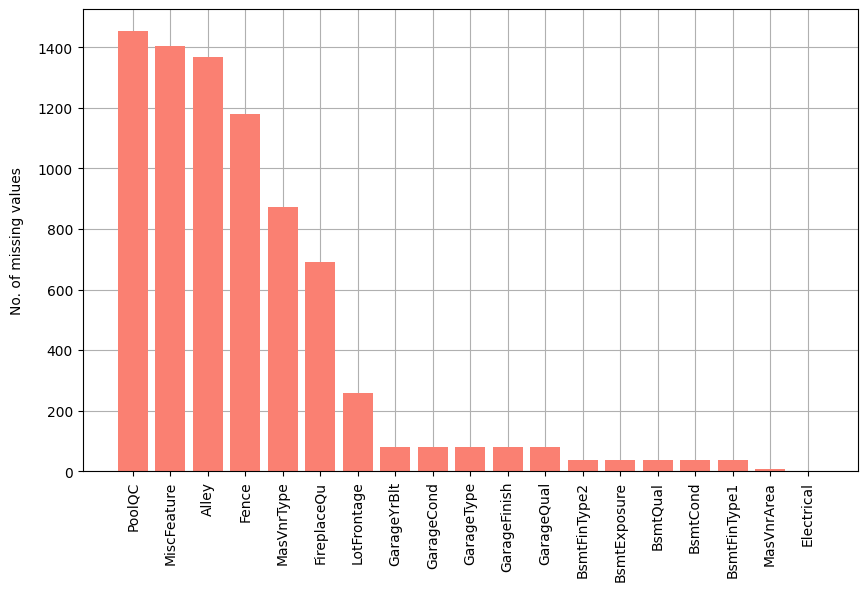

In [45]:
nans = df.isna().sum().sort_values(ascending=False)
nans = nans[nans > 0]
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()
ax.bar(nans.index, nans.values, zorder=2, color='salmon')
ax.set_ylabel("No. of missing values", labelpad=10)

ax.xaxis.set_tick_params(rotation=90)
plt.show()

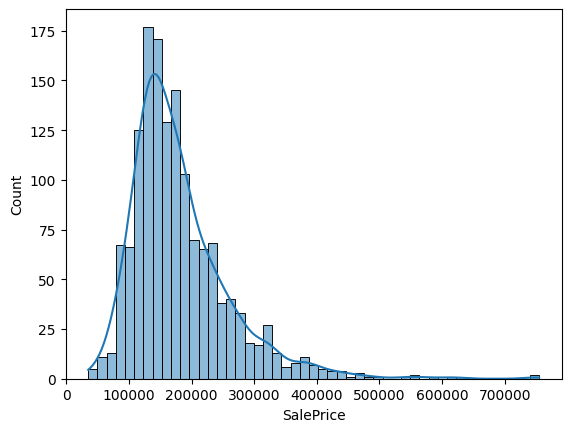

In [46]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

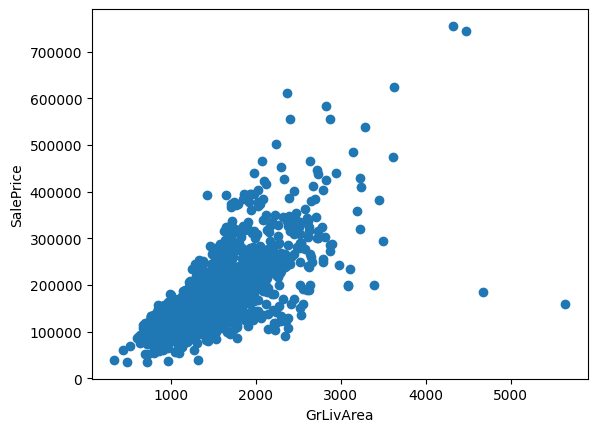

In [47]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

In [48]:
df.drop('Id', axis=1, inplace=True)
df2.drop('Id', axis=1, inplace=True)

In [49]:
Categorical_missing = df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)
Categorical_missing = Categorical_missing[Categorical_missing > 0]
Categorical_missing


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageCond        81
GarageQual        81
GarageFinish      81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtQual          37
BsmtCond          37
Electrical         1
dtype: int64

In [50]:
Numeric_missing = df.select_dtypes(include=['float64', 'int64']).isnull().sum().sort_values(ascending=False)
Numeric_missing = Numeric_missing[Numeric_missing > 0]
Numeric_missing

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [51]:
cols_none = {'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageCond', 'GarageQual', 'GarageFinish','BsmtFinType2','BsmtExposure','BsmtFinType1','BsmtCond','BsmtQual'}

for col in cols_none:
    df[col] = df[col].fillna('None')

cols_zero = {'GarageYrBlt', 'MasVnrArea'}

for col in cols_zero:
    df[col] = df[col].fillna(0)

cols_median = {'LotFrontage'}

for col in cols_median:
    df[col] = df[col].fillna(df[col].median())

cols_mode = {'Electrical'}

for col in cols_mode:
    df[col] = df[col].fillna(df[col].mode()[0])



In [52]:
missing_test = df2.isna().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]
missing_test


PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageFinish      78
GarageQual        78
GarageCond        78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType2      42
BsmtFinType1      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Functional         2
Utilities          2
BsmtFullBath       2
KitchenQual        1
BsmtFinSF1         1
SaleType           1
TotalBsmtSF        1
GarageCars         1
Exterior2nd        1
Exterior1st        1
GarageArea         1
BsmtUnfSF          1
BsmtFinSF2         1
dtype: int64

In [53]:
cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]

for col in cols_none:
    df2[col] = df2[col].fillna('None')

cols_zero = ["GarageYrBlt", "GarageCars", "GarageArea",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]

for col in cols_zero:
    df2[col] = df2[col].fillna(0)

df2["LotFrontage"] = df2.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )
cols_mode = ["Electrical", "MSZoning", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType"]

for col in cols_mode:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

In [54]:
df = df.drop(["Utilities", "Functional"], axis=1)
df2 = df2.drop(["Utilities", "Functional"], axis=1)

In [55]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df2["TotalSF"] = df2["TotalBsmtSF"] + df2["1stFlrSF"] + df2["2ndFlrSF"]

df["TotalBath"] = (
    df["FullBath"] + 
    0.5 * df["HalfBath"] + 
    df["BsmtFullBath"] + 
    0.5 * df["BsmtHalfBath"]
)
df2["TotalBath"] = (
    df2["FullBath"] + 
    0.5 * df2["HalfBath"] + 
    df2["BsmtFullBath"] + 
    0.5 * df2["BsmtHalfBath"]
)

df["HasGarage"] = df["GarageArea"].apply(lambda x: 1 if x > 0 else 0)
df["HasBsmt"] = df["TotalBsmtSF"].apply(lambda x: 1 if x > 0 else 0)
df["Has2ndFlr"] = df["2ndFlrSF"].apply(lambda x: 1 if x > 0 else 0)
df["HasFireplace"] = df["Fireplaces"].apply(lambda x: 1 if x > 0 else 0)
df["HasPool"] = df["PoolArea"].apply(lambda x: 1 if x > 0 else 0)

df2["HasGarage"] = df2["GarageArea"].apply(lambda x: 1 if x > 0 else 0)
df2["HasBsmt"] = df2["TotalBsmtSF"].apply(lambda x: 1 if x > 0 else 0)
df2["Has2ndFlr"] = df2["2ndFlrSF"].apply(lambda x: 1 if x > 0 else 0)
df2["HasFireplace"] = df2["Fireplaces"].apply(lambda x: 1 if x > 0 else 0)
df2["HasPool"] = df2["PoolArea"].apply(lambda x: 1 if x > 0 else 0)


In [56]:
categorical_features = [
    "MSSubClass", "MSZoning", "Street", "Alley", "LotShape", "LandContour", 
    "Utilities", "LotConfig", "LandSlope", "Neighborhood", "Condition1", 
    "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", 
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", 
    "CentralAir", "Electrical", "GarageType", "GarageFinish", 
    "PavedDrive", "MiscFeature", "SaleType", "SaleCondition", "MoSold"
]

for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype("category")

for col in categorical_features:
    if col in df2.columns:
        df2[col] = df2[col].astype("category")


numeric_features = df2.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_features:
    if col in df.columns:
        df[col] = df[col].astype(float)

for col in numeric_features:
    if col in df2.columns:
        df2[col] = df2[col].astype(float)


print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Categorical features: 30
Numeric features: 41


In [57]:
# Get the categorical columns with low cardinality for both datasets
low_cardinality_cols = [col for col in df.select_dtypes(include="category") if df[col].nunique() <= 10]

# Create dummy variables for both datasets together to ensure same columns
df_combined = pd.get_dummies(pd.concat([df, df2])[low_cardinality_cols], drop_first=True)

# Split back into train and test
df_dummy = df_combined.iloc[:len(df), :]
df2_dummy = df_combined.iloc[len(df):, :]

# Replace the categorical columns with dummy variables
df = pd.concat([df.drop(columns=low_cardinality_cols), df_dummy], axis=1)
df2 = pd.concat([df2.drop(columns=low_cardinality_cols), df2_dummy], axis=1) 


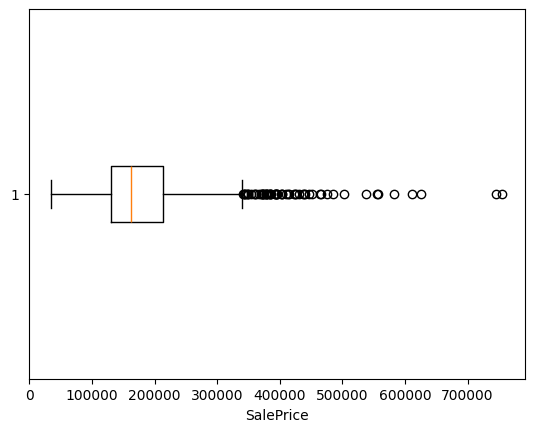

In [58]:
df['SalePrice'].describe()

plt.boxplot(df['SalePrice'],vert= False)
plt.xlabel('SalePrice')

plt.show()

In [61]:
df = df[df["GrLivArea"] < 4000]
df = df[df['SalePrice'] < 350000]

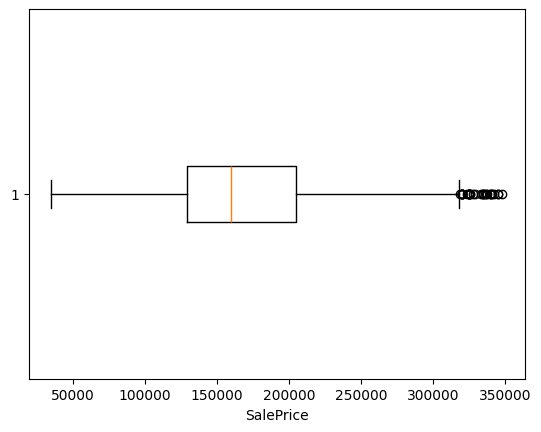

In [62]:
df['SalePrice'].describe()

plt.boxplot(df['SalePrice'],vert= False)
plt.xlabel('SalePrice')

plt.show()

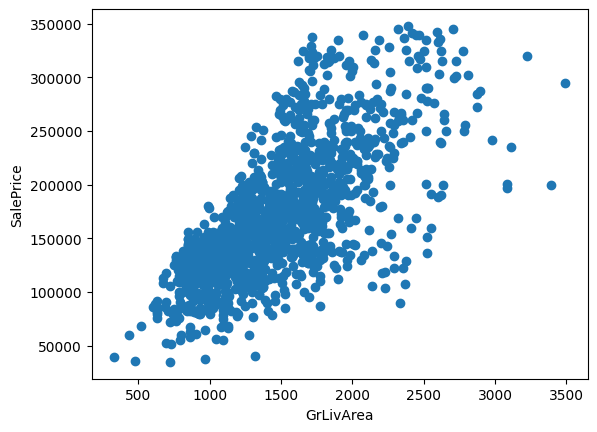

In [63]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

In [64]:
df["SalePrice"] = np.log1p(df["SalePrice"])


In [65]:
df = pd.get_dummies(df, drop_first=True)
df2 = pd.get_dummies(df2, drop_first=True)

In [66]:
df,df2 = df.align(df2, join='left', axis=1, fill_value=0)
df2 = df2.drop(['SalePrice'], axis=1)

In [67]:
df.shape

(1402, 283)

In [68]:
df2.shape

(1459, 282)

Correlation Matrix

In [ ]:
def validate_datasets(train, test):
    print("Validation Checks:")
    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")
    print("\nMissing values in train:", train.isnull().sum().sum())
    print("Missing values in test:", test.isnull().sum().sum())
    print("\nInfinite values in train:", np.isinf(train.select_dtypes(include=['float64'])).sum().sum())
    print("Infinite values in test:", np.isinf(test.select_dtypes(include=['float64'])).sum().sum())
    
validate_datasets(df, df2)


Validation Checks:
Train shape: (1402, 283)
Test shape: (1459, 282)

Missing values in train: 0
Missing values in test: 0

Infinite values in train: 0
Infinite values in test: 0


In [70]:
df.to_csv('dataset/train_cleaned.csv', index=False)
df2.to_csv('dataset/test_cleaned.csv', index=False)

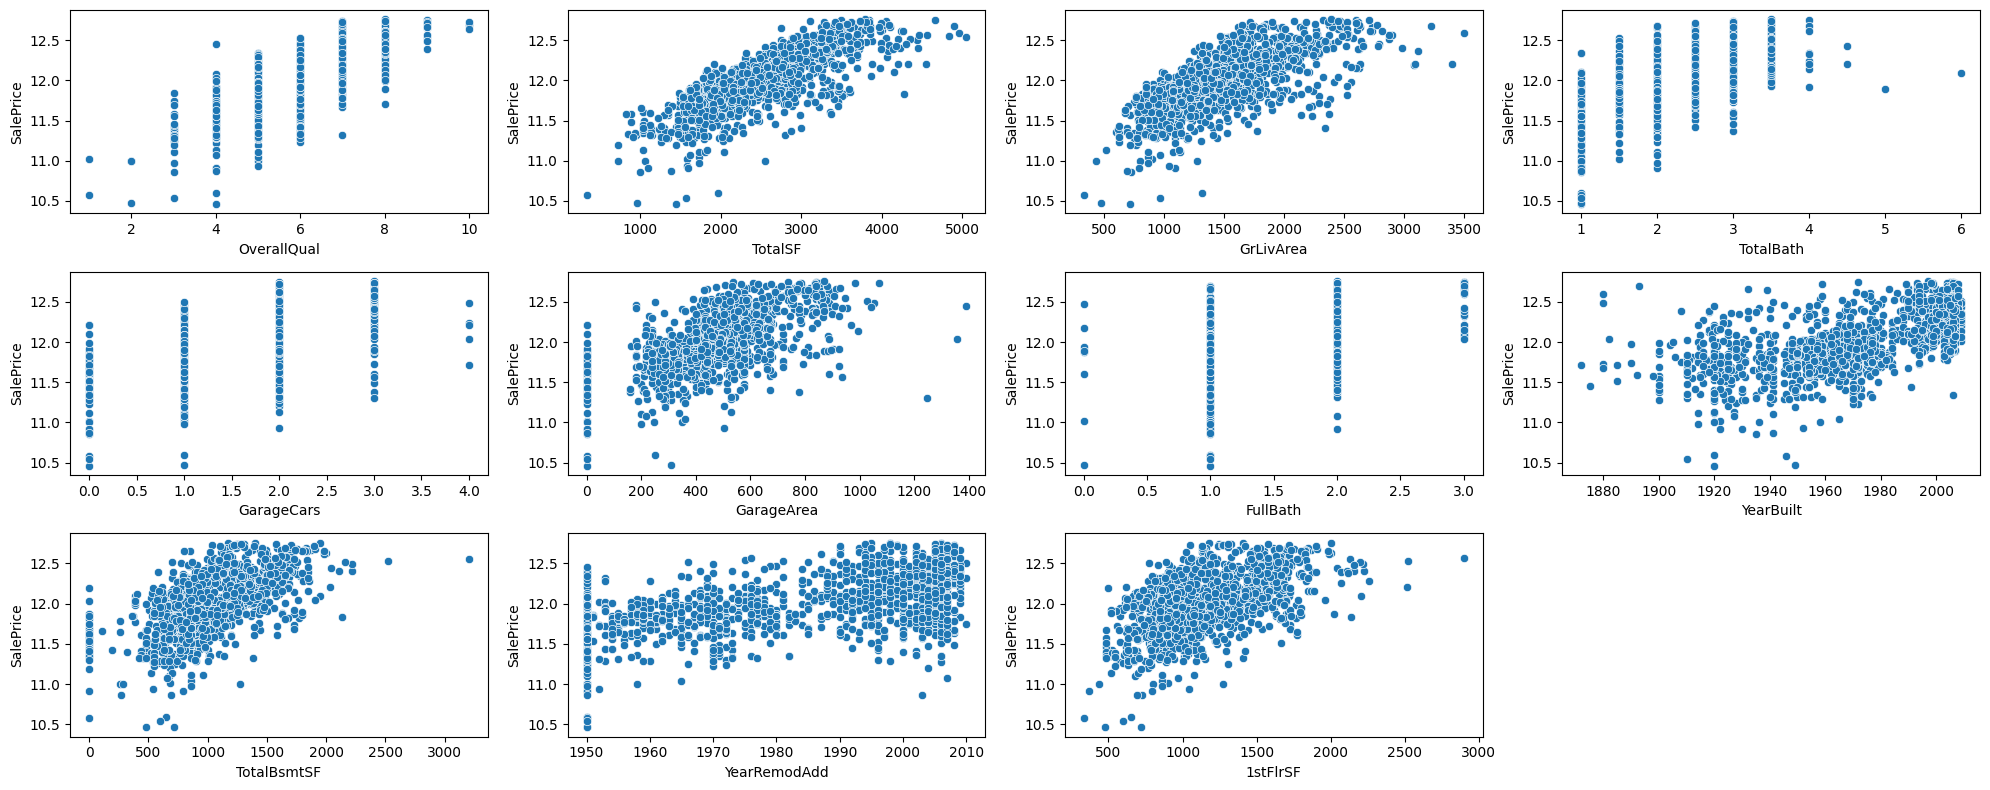

In [71]:
most_correlated_numeric = df.select_dtypes(include=['float64', 'int64']).corr()['SalePrice'].sort_values(ascending=False).head(12)
most_correlated_numeric = most_correlated_numeric.drop('SalePrice')

plt.figure(figsize=(20, 8))

for i, col in enumerate(most_correlated_numeric.index):
    plt.subplot(3, 4, i + 1)
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.xlabel(col)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()